STEP 1:

In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
#read counts data
expr = pd.read_csv("SRP_counts.tsv.gz", sep="\t", index_col="Gene")
meta = pd.read_csv("metadata.tsv.gz", sep="\t")

assert list(expr.columns) == meta.refinebio_accession_code.tolist() #make sure samples match in metadata and expr matrix
print("genes x samples:", expr.shape)

genes x samples: (43363, 335)


In [6]:
#read metadata and separate into brain areas and disorders
meta[["region", "dx"]] = meta.refinebio_subject.str.split("_", n=1, expand=True)
meta["donor"] = meta.refinebio_title.str.split("_").str[0]

print(pd.crosstab(meta.dx, meta.region))
print("unique donors:", meta.donor.nunique())

region            ancg  dlpfc  nacc
dx                                 
bipolar disorder    25     28    30
control             28     28    27
major depression    27     30    32
schizophrenia       27     28    25
unique donors: 96


In [7]:
#each library is the specific patient sample from each region sampled. Here I look for and merged duplicates
run_to_lib = meta.set_index("refinebio_accession_code").refinebio_title
print("duplicate runs:", run_to_lib.duplicated().sum())

expr_lib = expr.T.groupby(run_to_lib).mean().T
meta_lib = (meta.drop_duplicates("refinebio_title").set_index("refinebio_title").loc[expr_lib.columns])

print("genes x libraries:", expr_lib.shape)

#found 69 duplicates, so we actually have 266 libraries total

duplicate runs: 69
genes x libraries: (43363, 266)


In [8]:
#5 log-scale the data (the range of data before is to confirm the data is not log-scaled yet, only quantile normalized)
print("range before log:", expr_lib.values.min(), expr_lib.values.max())
log_expr = np.log2(expr_lib + 1)
#we have to add 1 or else log-scaling breaks with the negative values from quantile normalization

range before log: -0.1583617006285569 197.4761356701856


In [9]:
#how much variation do you see in the data? (per gene median expression ranges) 
medians = log_expr.median(axis=1)
spread = log_expr.max(axis=1) - log_expr.min(axis=1)

print(medians.describe())
print("genes with median <= 0:", (medians <= 0).sum())
print(spread.describe())

count    43363.000000
mean         1.092880
std          1.154176
min         -0.098697
25%          0.181527
50%          0.767416
75%          1.723796
max          7.632822
dtype: float64
genes with median <= 0: 8165
count    43363.000000
mean         1.104323
std          0.650898
min          0.341434
25%          0.684684
50%          0.879574
75%          1.260153
max          6.202458
dtype: float64


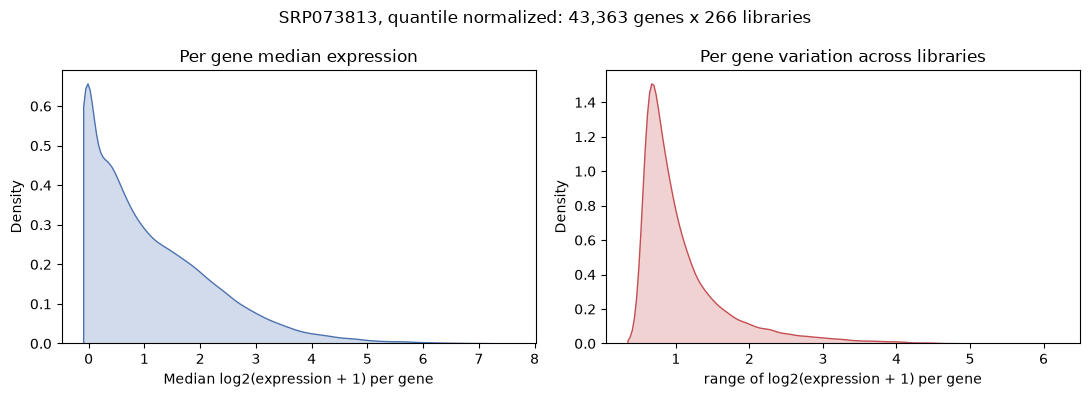

In [10]:
#density plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.kdeplot(medians, fill=True, cut=0, color="#4C72B0", ax=axes[0])
axes[0].set_xlabel("Median log2(expression + 1) per gene")
axes[0].set_ylabel("Density")
axes[0].set_title("Per gene median expression")

sns.kdeplot(spread, fill=True, cut=0, color="#C44E52", ax=axes[1])
axes[1].set_xlabel("range of log2(expression + 1) per gene")
axes[1].set_ylabel("Density")
axes[1].set_title("Per gene variation across libraries")

fig.suptitle(f"SRP073813, quantile normalized: {expr_lib.shape[0]:,} genes x {expr_lib.shape[1]} libraries")
fig.tight_layout()
fig.savefig("plots/step1_density_medians.png", dpi=200, bbox_inches="tight")

In [11]:
#convert the Ensembl IDs to gene names with mygene. 
import mygene

mg = mygene.MyGeneInfo()
results = mg.querymany(expr_lib.index.tolist(), scopes="ensembl.gene", fields="symbol", species="human")

res = pd.DataFrame(results)
print("rows returned:", len(res), "vs queried:", len(expr_lib))
print("multi-hit IDs:", res["query"].duplicated().sum())

#there's 28 duplicate names that we need to get rid of or else all the later genes are unmatched because of offset
symbols = (res.drop_duplicates("query")
              .set_index("query")["symbol"]
              .reindex(expr_lib.index))

print("no symbol:", symbols.isna().sum())
symbols.rename("symbol").rename_axis("ensembl_id").to_csv("gene_symbols.tsv", sep="\t")

28 input query terms found dup hits:	[('ENSG00000117262', 2), ('ENSG00000188092', 2), ('ENSG00000188660', 2), ('ENSG00000226506', 2), ('E
1232 input query terms found no hit:	['ENSG00000112096', 'ENSG00000116883', 'ENSG00000130489', 'ENSG00000130723', 'ENSG00000131484', 'ENS


rows returned: 43406 vs queried: 43363
multi-hit IDs: 43
no symbol: 10172


In [13]:
expr_lib.to_csv("data/expr_by_library.tsv.gz", sep="\t")
meta_lib.to_csv("data/meta_by_library.tsv", sep="\t")

STEP 2:

In [1]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

c:\Users\danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [45]:
#load merged data from step 1 and then separates to do plots on anterior cingulate region
expr = pd.read_csv("data/expr_by_library.tsv.gz", sep="\t", index_col=0)
meta = pd.read_csv("data/meta_by_library.tsv", sep="\t", index_col=0)

sl = meta.index.str.extract(r"SL(\d+)")[0].astype(int).values
meta["batch"] = np.where(sl > 20000, "B", "A")

keep = meta[(meta.region == "ancg") & (meta.dx != "major depression")].copy()
keep["group"] = np.where(keep.dx == "control", "Control", "SZ+BPD")

print(keep.group.value_counts())
print(keep.dx.value_counts())

group
SZ+BPD     45
Control    22
Name: count, dtype: int64
dx
schizophrenia       23
control             22
bipolar disorder    22
Name: count, dtype: int64


In [46]:
#log scale and filter genes with zero expression (about 8000) before doing plots
log_expr = np.log2(expr[keep.index] + 1)
log_expr = log_expr[log_expr.median(axis=1) > 0]
print("genes kept:", log_expr.shape[0])

genes kept: 35050


In [47]:
#select 500 most variable genes to do PCA
top = log_expr.var(axis=1).sort_values(ascending=False).index[:500]
X = log_expr.loc[top].T

In [41]:
pca = PCA(n_components=10).fit(X)
pcs = pca.transform(X)
var = pca.explained_variance_ratio_ * 100
print("variance explained (%):", var[:5].round(1))

variance explained (%): [34.1 14.9  9.9  6.2  3.7]


In [42]:
tsne = TSNE(n_components=2, perplexity=15, random_state=42, init="pca").fit_transform(X)
um = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=42).fit_transform(X)

c:\Users\danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [43]:
#plots

colors = {"Control": "#1f77b4", "Disorder": "#d62728"}
panels = [
    (pcs[:, :2], f"PC1 ({var[0]:.1f}% variance)", f"PC2 ({var[1]:.1f}% variance)", "PCA", "pca"),
    (tsne, "t-SNE 1", "t-SNE 2", "t-SNE (perplexity 15)", "tsne"),
    (um, "UMAP 1", "UMAP 2", "UMAP (n_neighbors 15)", "umap"),
]

for coords, xl, yl, title, fname in panels:
    fig, ax = plt.subplots(figsize=(6, 5))
    for g, c in colors.items():
        mask = (keep.group == g).values
        ax.scatter(coords[mask, 0], coords[mask, 1], c=c,
                   label=f"{g} (n={mask.sum()})", s=40, alpha=0.75,
                   edgecolor="k", linewidth=0.3)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f"{title}: AnCg, control vs any disorder")
    ax.legend(title="Group")
    fig.savefig(f"plots/step2_{fname}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

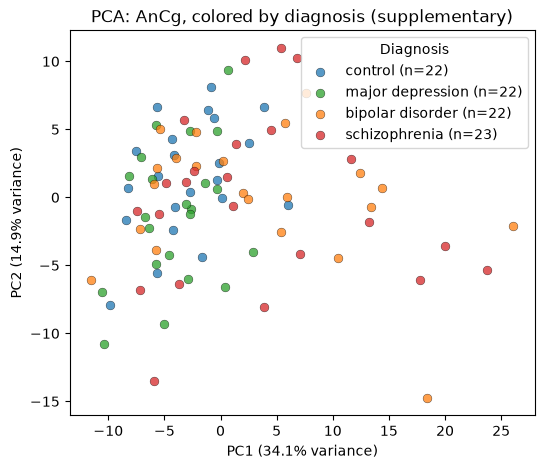

In [ ]:
#extra plot separated by disease that shows how depression aligns with control, but bipolar and schizophrenia align more with each other
dx_colors = {
    "control": "#1f77b4",
    "major depression": "#2ca02c",
    "bipolar disorder": "#ff7f0e",
    "schizophrenia": "#d62728",
}

fig, ax = plt.subplots(figsize=(6, 5))
for d, c in dx_colors.items():
    mask = (keep.dx == d).values
    ax.scatter(pcs[mask, 0], pcs[mask, 1], c=c,
               label=f"{d} (n={mask.sum()})", s=40, alpha=0.75,
               edgecolor="k", linewidth=0.3)
ax.set_xlabel(f"PC1 ({var[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var[1]:.1f}% variance)")
ax.set_title("PCA: AnCg, colored by diagnosis (supplementary)")
ax.legend(title="Diagnosis")
fig.savefig("plots/step2_pca_by_diagnosis.png", dpi=200, bbox_inches="tight")

Step 3: Control vs any disorder gave no significant genes, so I chose to do control vs schizophrenia + bipolar (since depression aligns really well with the control it was dropped from "disorders")

In [49]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [ ]:
#log scale and filter just like step 2, we have 67 libraries since depression was dropped
log_expr = np.log2(expr[keep.index] + 1)
log_expr = log_expr[log_expr.median(axis=1) > 0]
print(log_expr.shape)

(35050, 67)


In [ ]:
#split samples into control and schizophrenia + bipolar. difference in means is the log2 fold change.
ctrl = log_expr.loc[:, keep.group == "Control"]
case = log_expr.loc[:, keep.group == "SZ+BPD"]

log2fc = case.mean(axis=1) - ctrl.mean(axis=1)

In [ ]:
#run a welch t test for each gene. 
tt = stats.ttest_ind(case, ctrl, axis=1, equal_var=False)

c:\Users\danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:644: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


In [ ]:
#combine results into one table and apply the p-value correction (benjamini-hochberg) to account for random chance
res = pd.DataFrame({
    "log2FC": log2fc,
    "t": tt.statistic,
    "pvalue": tt.pvalue,
}, index=log_expr.index)

res["padj"] = multipletests(res.pvalue, method="fdr_bh")[1]

In [ ]:
#call genes up or down regulated (or not signicant change), as long as they have a adjusted p below 0.05 and log fold change above 0.1
symbols = pd.read_csv("gene_symbols.tsv", sep="\t", index_col=0)["symbol"]
res.insert(0, "symbol", symbols.reindex(res.index))

res["significant"] = np.where(
    (res.padj < 0.05) & (res.log2FC > 0.1), "Up",
    np.where((res.padj < 0.05) & (res.log2FC < -0.1), "Down", "Not significant"))

print(res.significant.value_counts())

significant
Not significant    32231
Down                1692
Up                  1127
Name: count, dtype: int64


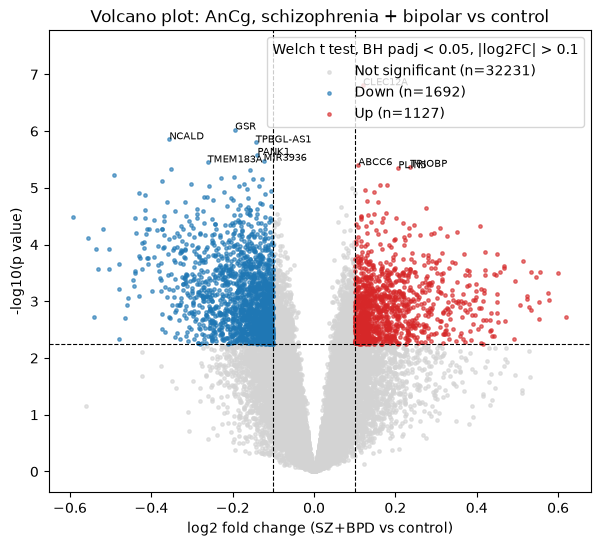

In [ ]:
#volcano plot
res["neglog10p"] = -np.log10(res.pvalue)

colors = {"Not significant": "lightgray", "Down": "#1f77b4", "Up": "#d62728"}
fig, ax = plt.subplots(figsize=(7, 6))
for lab, c in colors.items():
    sub = res[res.significant == lab]
    ax.scatter(sub.log2FC, sub.neglog10p, c=c, s=6, alpha=0.6,
               label=f"{lab} (n={len(sub)})")

p_cut = res.loc[res.padj < 0.05, "pvalue"].max()
ax.axhline(-np.log10(p_cut), ls="--", c="k", lw=0.8)
ax.axvline(0.1, ls="--", c="k", lw=0.8)
ax.axvline(-0.1, ls="--", c="k", lw=0.8)

for gene, row in res[res.significant != "Not significant"].nsmallest(10, "pvalue").iterrows():
    ax.annotate(row.symbol if pd.notna(row.symbol) else gene,
                (row.log2FC, row.neglog10p), fontsize=7)

ax.set_xlabel("log2 fold change (SZ+BPD vs control)")
ax.set_ylabel("-log10(p value)")
ax.set_title("Volcano plot: AnCg, schizophrenia + bipolar vs control")
ax.legend(title="Welch t test, BH padj < 0.05, |log2FC| > 0.1")
fig.savefig("plots/step3_volcano.png", dpi=200, bbox_inches="tight")

In [ ]:
#save full results tabe and top 50 most significant genes. Table should be used for enrichment in step 5.
res = res.sort_values("pvalue")
res.drop(columns="neglog10p").to_csv("results-daniel/step3_DE_results_all.tsv", sep="\t")

top50 = res[res.significant != "Not significant"].head(50)
top50.drop(columns="neglog10p").to_csv("results-daniel/step3_top50_DE_genes.tsv", sep="\t")
top50[["symbol", "log2FC", "pvalue", "padj", "significant"]]

,symbol,log2FC,pvalue,padj,significant
Gene,,,,,
ENSG00000172322,CLEC12A,0.120650,1.552423e-07,0.002721,Up
ENSG00000104687,GSR,-0.193907,9.381005e-07,0.010960,Down
ENSG00000104490,NCALD,-0.355675,1.396624e-06,0.011116,Down
ENSG00000255136,TPBGL-AS1,-0.143147,1.585667e-06,0.011116,Down
ENSG00000152782,PANK1,-0.139014,2.626626e-06,0.012205,Down
ENSG00000263597,MIR3936,-0.123970,3.335542e-06,0.012205,Down
ENSG00000163444,TMEM183A,-0.261508,3.563275e-06,0.012205,Down
ENSG00000091262,ABCC6,0.108856,3.987279e-06,0.012205,Up
ENSG00000100106,TRIOBP,0.236528,4.263292e-06,0.012205,Up


Step 4:

In [58]:
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import fcluster

In [ ]:
#select the significant genes and z score to map the z-scores, not total expression
sig_genes = res.index[res.significant != "Not significant"]
mat = log_expr.loc[sig_genes]

z = mat.sub(mat.mean(axis=1), axis=0).div(mat.std(axis=1), axis=0)
print(z.shape)

(2819, 67)


In [ ]:
#colors
group_pal = {"Control": "#1b9e77", "SZ+BPD": "#7570b3"}
dx_pal = {"control": "#1b9e77", "schizophrenia": "#d95f02", "bipolar disorder": "#e6ab02"}
dir_pal = {"Up": "#b2182b", "Down": "#2166ac"}

col_colors = pd.DataFrame({
    "Group": keep.group.map(group_pal),
    "Diagnosis": keep.dx.map(dx_pal),
}, index=keep.index)

row_colors = res.loc[sig_genes, "significant"].map(dir_pal).rename("Direction")

c:\Users\danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


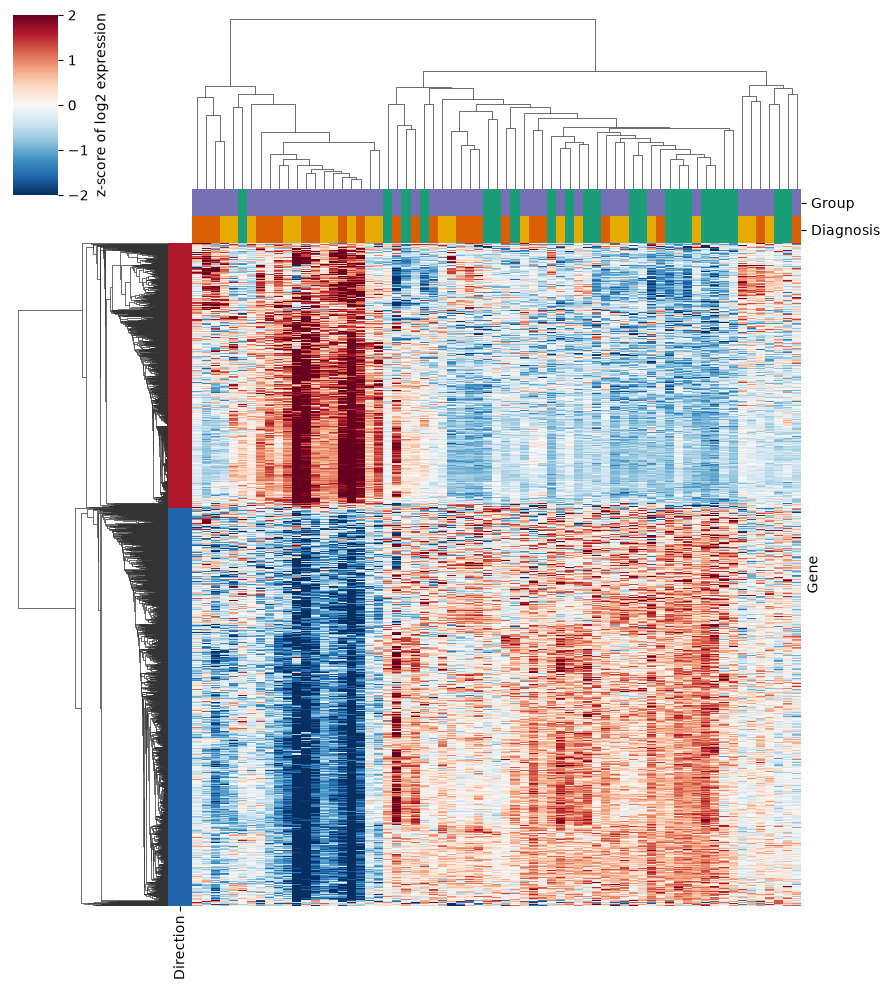

In [ ]:
#draw the clustered heatmap 
g = sns.clustermap(
    z,
    col_colors=col_colors,
    row_colors=row_colors,
    cmap="RdBu_r", center=0, vmin=-2, vmax=2,
    method="average", metric="correlation",
    xticklabels=False, yticklabels=False,
    figsize=(9, 10),
    cbar_kws={"label": "z-score of log2 expression"},
)

In [ ]:
#add legend, labels, and title, and save to plots
handles = (
    [Patch(color="none", label="Group")]
    + [Patch(color=c, label=l) for l, c in group_pal.items()]
    + [Patch(color="none", label=""), Patch(color="none", label="Diagnosis")]
    + [Patch(color=c, label=l) for l, c in dx_pal.items()]
    + [Patch(color="none", label=""), Patch(color="none", label="Direction")]
    + [Patch(color=c, label=f"{l} in SZ+BPD") for l, c in dir_pal.items()]
)
g.ax_heatmap.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.15, 1.3), frameon=False, fontsize=8)

g.fig.suptitle(f"{len(sig_genes):,} significant genes, AnCg SZ+BPD vs control", y=1.02)
g.ax_heatmap.set_xlabel(f"Libraries (n={z.shape[1]})")
g.ax_heatmap.set_ylabel("Genes")
g.savefig("plots/step4_heatmap.png", dpi=200, bbox_inches="tight")

In [ ]:
#cut sample into two clusters to see what the clustering separated 
clusters = fcluster(g.dendrogram_col.linkage, 2, "maxclust")
print(pd.crosstab(pd.Series(clusters, index=z.columns, name="cluster"), keep.dx))
print(pd.crosstab(pd.Series(clusters, index=z.columns, name="cluster"), keep.batch))

dx       bipolar disorder  control  schizophrenia
cluster                                          
1                      10        1             10
2                      12       21             13
batch     A   B
cluster        
1        19   2
2        35  11
